In [1]:
import pypsa
import matplotlib.pyplot as plt
plt.style.use("bmh")

In [2]:
n = pypsa.Network("/home/eduque/pypsa-earth/results/postnetworks/elec_s_3flex_ec_lcopt_Co2L-4H_144h_2030_0.071_AB_10export.nc") 
#n = pypsa.Network("networks/network_za/solved_2Gt-UNC-IRP2023_11-supply_redz_lcopt_LC-Co2L-2H.nc") 

# elec_s: electricity system
# 6: 6 nodes in total
# lcopt: optimised system
# Co2L: CO2 budget limit
# 4H: four hourly temporal resolution

INFO:pypsa.io:Imported network elec_s_3flex_ec_lcopt_Co2L-4H_144h_2030_0.071_AB_10export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [3]:
n

PyPSA Network
Components:
 - Bus: 76
 - Carrier: 38
 - Generator: 123
 - GlobalConstraint: 1
 - Line: 2
 - Link: 183
 - Load: 101
 - StorageUnit: 3
 - Store: 51
Snapshots: 61

/home/eduque/anaconda3/envs/pypsa-earth/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x7fb1f1a29c90>,
 <matplotlib.collections.LineCollection at 0x7fb1f0e8e2f0>)

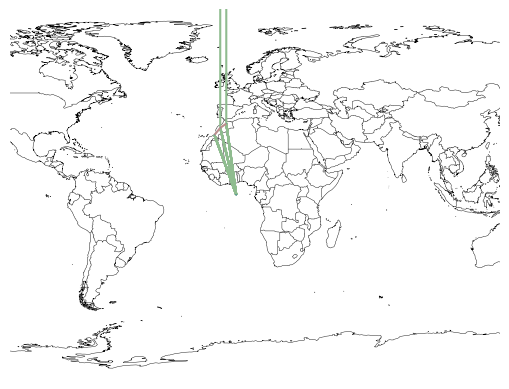

In [4]:
n.plot()

In [5]:
n.snapshots # temporal resolution

DatetimeIndex(['2013-01-01', '2013-01-07', '2013-01-13', '2013-01-19',
               '2013-01-25', '2013-01-31', '2013-02-06', '2013-02-12',
               '2013-02-18', '2013-02-24', '2013-03-02', '2013-03-08',
               '2013-03-14', '2013-03-20', '2013-03-26', '2013-04-01',
               '2013-04-07', '2013-04-13', '2013-04-19', '2013-04-25',
               '2013-05-01', '2013-05-07', '2013-05-13', '2013-05-19',
               '2013-05-25', '2013-05-31', '2013-06-06', '2013-06-12',
               '2013-06-18', '2013-06-24', '2013-06-30', '2013-07-06',
               '2013-07-12', '2013-07-18', '2013-07-24', '2013-07-30',
               '2013-08-05', '2013-08-11', '2013-08-17', '2013-08-23',
               '2013-08-29', '2013-09-04', '2013-09-10', '2013-09-16',
               '2013-09-22', '2013-09-28', '2013-10-04', '2013-10-10',
               '2013-10-16', '2013-10-22', '2013-10-28', '2013-11-03',
               '2013-11-09', '2013-11-15', '2013-11-21', '2013-11-27',
      

In [6]:
len(n.snapshots)

61

In [7]:
n.lines.head(10)

,num_parallel,v_nom,bus0,bus1,length,dc,geometry,bounds,carrier,type,...,build_year,lifetime,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu
Line,,,,,,,,,,,,,,,,,,,,,
0,1.006579,380.0,MA0_AC,MA1_AC,582.016639,False,"MULTILINESTRING ((-9.7502 29.1511, -9.7501061 ...","MULTIPOINT ((-9.7502 29.1511), (-9.7501061 29....",AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
1,11.881579,380.0,MA1_AC,MA2_AC,440.191262,False,"MULTILINESTRING ((-7.42752 33.55806529999997, ...","MULTIPOINT ((-7.4817 33.5474), (-7.42752 33.55...",AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0


In [8]:
n.buses.index.unique()

Index(['MA0_AC', 'MA1_AC', 'MA2_AC', 'co2 atmosphere', 'MA0_AC co2 stored',
       'MA1_AC co2 stored', 'MA2_AC co2 stored', 'MA0_AC gas', 'MA1_AC gas',
       'MA2_AC gas', 'MA0_AC oil', 'MA1_AC oil', 'MA2_AC oil', 'MA0_AC coal',
       'MA1_AC coal', 'MA2_AC coal', 'Earth lignite', 'MA0_AC solid biomass',
       'MA1_AC solid biomass', 'MA2_AC solid biomass', 'MA0_AC H2',
       'MA1_AC H2', 'MA2_AC H2', 'MA0_AC battery', 'MA1_AC battery',
       'MA2_AC battery', 'MA0_AC residential rural heat',
       'MA1_AC residential rural heat', 'MA2_AC residential rural heat',
       'MA0_AC residential rural water tanks',
       'MA1_AC residential rural water tanks',
       'MA2_AC residential rural water tanks', 'MA0_AC services rural heat',
       'MA1_AC services rural heat', 'MA2_AC services rural heat',
       'MA0_AC services rural water tanks',
       'MA1_AC services rural water tanks',
       'MA2_AC services rural water tanks',
       'MA0_AC residential urban decentral heat',
   

In [23]:
n.buses[n.buses.carrier =="AC"]

In [25]:
#Resuts
n.statistics.energy_balance().dropna().xs("AC",level="bus_carrier").div(1e6).round(1)

component    carrier                           
StorageUnit  Pumped Hydro Storage                  -0.0
             Reservoir & Dam                        3.9
Generator    Combined-Cycle Gas                     0.0
             Offshore Wind (DC)                     0.0
             Onshore Wind                           3.3
             Run of River                           4.2
             Solar                                  3.1
Link         DAC                                   -0.0
             Fischer-Tropsch                       -0.0
             H2 Electrolysis                       -0.0
             H2 Fuel Cell                           0.0
             OCGT                                   0.0
             battery charger                       -0.0
             battery discharger                     0.0
             biomass EOP                            0.0
             coal                                   0.0
             electricity distribution grid        -21.5


In [27]:
n.statistics.energy_balance().dropna().xs("oil",level="bus_carrier").div(1e6).round(1)

component  carrier              
Store      oil                      72.7
Load        rail transport oil      -0.2
           agriculture oil          -8.5
           kerosene for aviation   -12.6
           land transport oil        3.0
           naphtha for industry    -32.1
           residential oil          -0.0
           services oil             -0.0
           shipping oil             -1.9
Generator  oil                       0.0
Link       Fischer-Tropsch           0.0
           oil                     -20.3
dtype: float64

In [28]:
n.statistics.set_parameters(nice_names=False, drop_zero=False, round=5)

AttributeError: 'StatisticsAccessor' object has no attribute 'set_parameters'

In [34]:
n.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
Carrier,,,,,
nuclear,0.000,#ff9000,Nuclear,inf,0.0
CCGT,0.198,#b80404,Combined-Cycle Gas,inf,0.0
geothermal,0.120,#ba91b1,Geothermal,inf,0.0
hydro,0.000,#08ad97,Reservoir & Dam,inf,0.0
offwind-ac,0.000,#6895dd,Offshore Wind (AC),inf,0.0
offwind-dc,0.000,#74c6f2,Offshore Wind (DC),inf,0.0
onwind,0.000,#235ebc,Onshore Wind,inf,0.0
solar,0.000,#f9d002,Solar,inf,0.0
PHS,0.000,#08ad97,Pumped Hydro Storage,inf,0.0


In [31]:
pypsa.__version__

'0.28.0'

In [33]:
n.statistics.optimal_capacity(comps=["Generator", "Link", "StorageUnit"], bus_carrier="AC").dropna().div(1e3).round(1)

component    carrier                      
Generator    Combined-Cycle Gas                     3.6
             Offshore Wind (DC)                     0.0
             Onshore Wind                           1.8
             Run of River                           0.5
             Solar                                  1.9
             load                             3000000.0
Link         H2 Electrolysis                        0.0
             battery charger                        0.0
             electricity distribution grid          2.5
             helmeth                                0.0
StorageUnit  Pumped Hydro Storage                   0.8
             Reservoir & Dam                        1.2
Name: p_nom_opt, dtype: float64

In [11]:
import atlite
import cartopy.crs as ccrs
import xarray as xr
import geopandas as gpd

# import holoviews as hv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import pypsa
import shutil
from rasterio.plot import show
from atlite.gis import shape_availability, ExclusionContainer


plt.rcParams["figure.figsize"] = [7, 7]
%matplotlib inline

In [12]:
# change current directory to parent folder
import os
import sys

if not os.path.isdir("pypsa-earth"):
    os.chdir("../../..")
sys.path.append(os.getcwd()+"/pypsa-earth/scripts")

In [13]:
scenario_name = "shapes_030325"  # scenario name, default value is "" for tutorial or default configuration
                    # value shall be non null if a scenario name is specified under the "run" tag in the config file

scenario_subpath = scenario_name + "/" if scenario_name else ""

solar_path = os.getcwd() + "/pypsa-earth/resources/" + scenario_subpath + "renewable_profiles/profile_solar.nc"
solar = xr.open_dataset(solar_path)
solar

wind_path = os.getcwd() + "/pypsa-earth/resources/" + scenario_subpath + "/renewable_profiles/profile_onwind.nc"
wind = xr.open_dataset(wind_path)
wind

<xarray.Dataset>
Dimensions:           (time: 8760, bus: 370, y: 29, x: 42)
Coordinates:
  * time              (time) datetime64[ns] 2013-01-01 ... 2013-12-31T23:00:00
  * bus               (bus) <U3 '0' '3' '5' '7' '10' ... '452' '453' '454' '455'
  * y                 (y) float64 27.6 27.9 28.2 28.5 ... 35.1 35.4 35.7 36.0
  * x                 (x) float64 -13.2 -12.9 -12.6 -12.3 ... -1.5 -1.2 -0.9
Data variables:
    profile           (time, bus) float64 ...
    weight            (bus) float64 ...
    p_nom_max         (bus) float64 ...
    potential         (y, x) float64 ...
    average_distance  (bus) float64 ...

In [16]:
wind


<xarray.DataArray 'bus' (bus: 370)>
array(['0', '3', '5', ..., '453', '454', '455'], dtype='<U3')
Coordinates:
  * bus      (bus) <U3 '0' '3' '5' '7' '10' ... '451' '452' '453' '454' '455'